In [3]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

import os, math
from pathlib import Path
import scanpy as sc
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy import stats
from scipy.stats import pearsonr, spearmanr, gaussian_kde
from scipy.sparse import issparse
import pickle

import gseapy as gp

In [4]:
# for clustermap
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram
from scipy.spatial.distance import pdist

import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

In [ ]:
import matplotlib.colors as mcolors
from pycirclize import Circos
from collections import Counter

In [146]:
deg_df = pd.read_csv(
    "./data/sen_paper/2_pbDEGs_edgeR_NScFull.csv",
    index_col="gene_name",
)

In [149]:
import ast

all_terms = pd.read_csv(
    "./data/sen_paper/2.4.2_all_sen_terms_2.csv",
    index_col=0,
    converters={"geneSymbols": ast.literal_eval},
)

In [8]:
from collections import defaultdict

group2term_list = {
    "OIS": [
        "HALLMARK_KRAS_SIGNALING_UP",
        "HALLMARK_MTORC1_SIGNALING",
        "HALLMARK_PI3K_AKT_MTOR_SIGNALING",
        "REACTOME_ONCOGENE_INDUCED_SENESCENCE",
        "oncogene-induced cell senescence",
        "TOR signaling",
        "MAPK cascade",
        "stress-activated MAPK cascade",
    ],
    "TIS": [
        "response to xenobiotic stimulus",
        "response to ionizing radiation",
        "response to gamma radiation",
        "cellular response to UV",
        "DNA damage response",
        "DNA repair",
        "double-strand break repair",
        "HALLMARK_P53_PATHWAY",
        "HALLMARK_DNA_REPAIR",
        "REACTOME_DNA_REPAIR",
    ],
    "MS": [
        "HALLMARK_FATTY_ACID_METABOLISM",
        "HALLMARK_HYPOXIA",
        "HALLMARK_OXIDATIVE_PHOSPHORYLATION",
        "REACTOME_ENERGY_DEPENDENT_REGULATION_OF_MTOR_BY_LKB1_AMPK",
        # "REACTOME_METABOLISM_OF_RNA",
        "REACTOME_MITOCHONDRIAL_TRANSLATION",
        "phospholipid metabolic process",
        "fatty acid metabolic process",
        # "lipid metabolic process",
        "cellular response to nutrient levels",
        "response to starvation",
        "generation of precursor metabolites and energy",
        "response to hypoxia",
        "mitochondrion organization",
        "lysosomal lumen acidification",
        "mitophagy",
    ],
    "RS": [
        "GOBP_CELL_CYCLE_G1_S_PHASE_TRANSITION",
        "GOBP_REGULATION_OF_TELOMERE_MAINTENANCE_VIA_TELOMERASE",
        "GOBP_TELOMERE_MAINTENANCE_IN_RESPONSE_TO_DNA_DAMAGE",
        "REACTOME_DNA_DAMAGE_TELOMERE_STRESS_INDUCED_SENESCENCE",
        "REACTOME_TELOMERE_MAINTENANCE",
        "replicative senescence",
        "DNA replication",
        "telomere maintenance in response to DNA damage",
        "recombinational repair",
        "telomere maintenance",
        "telomere maintenance via recombination",
        "telomere organization",
        "negative regulation of telomere maintenance via telomerase",
        "regulation of telomere maintenance",
    ],
    "Common": [
        "negative regulation of apoptotic signaling pathway",
        "negative regulation of apoptotic process",
        "immune response-regulating signaling pathway",
        "response to type II interferon",
        "cellular response to cytokine stimulus",
        "negative regulation of inflammatory response",
        "HALLMARK_INFLAMMATORY_RESPONSE",
        "HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY",
        "REACTOME_CELLULAR_SENESCENCE",
        "REACTOME_ISG15_ANTIVIRAL_MECHANISM",
        "cellular senescence",
        "stress-induced premature senescence",
        "oxidative stress-induced premature senescence",
        "REACTOME_CELL_CYCLE_CHECKPOINTS",
        "REACTOME_DNA_DOUBLE_STRAND_BREAK_REPAIR",
        "REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT",
        "DNA damage response, signal transduction by p53 class mediator",
        "negative regulation of cell cycle",
        "G1 to G0 transition",
        "negative regulation of cell population proliferation",
        "response to oxidative stress",
        "cellular response to oxidative stress",
        "response to reactive oxygen species",
        "hydrogen peroxide catabolic process",
        "cytokine activity",
        "inflammatory response",
        "metalloendopeptidase activity",
        "production of molecular mediator involved in inflammatory response",
        "positive regulation of canonical NF-kappaB signal transduction",
        "chemokine production",
        "regulation of interleukin-6 production",
        "negative regulation of autophagy",
        "autophagy",
        "response to wounding",
        "viral process",
        "HALLMARK_G2M_CHECKPOINT",
        "response to stress",
    ],
}

In [150]:
# Перегруппировочка

# Создаем отображение term -> category
term2cat = {}

for cat, terms in group2term_list.items():
    for term in terms:
        term2cat[term] = cat

# Оставляем только термины из group2term_list
all_terms = all_terms.loc[all_terms["Term"].isin(term2cat)].copy()

# Добавляем категорию
all_terms["Term_cat"] = all_terms["Term"].map(term2cat)

### full prnkGSEA

In [152]:
out_path = "./data/sen_paper/2.6.1_prnkGSEA_sen_terms2_full.csv"

ct_results = []
for t in tqdm(sorted(deg_df.Tissue.unique()), desc="Processing Tissues"):
    t_degs = deg_df[deg_df.Tissue == t]
    for ct in sorted(t_degs.cell_type.unique()):
        ct_degs = t_degs[t_degs.cell_type == ct].copy()
        min_fdr = ct_degs["FDR"][ct_degs["FDR"] > 0].min()
        fdr_clean = ct_degs["FDR"].replace(0, min_fdr)

        # 1. Создаем множество уникальных разрешенных генов (для супер-быстрого поиска)
        allowed_genes = set(ct_degs.index.dropna())

        for cat in all_terms.Term_cat.unique():
            cat_terms_df = all_terms[all_terms.Term_cat == cat]
            filtered_cat_dict = (
                cat_terms_df.groupby("Term")["geneSymbols"]
                .apply(
                    lambda lists: list(
                        {
                            gene
                            for sublist in lists
                            for gene in sublist
                            if gene in allowed_genes
                        }
                    )
                )
                .to_dict()
            )

            pre_res = gp.prerank(
                rnk=ct_degs.sort_values(by=["logFC", "FDR"], ascending=[False, True])[
                    "logFC"
                ],
                outdir=None,
                gene_sets=filtered_cat_dict,
                ascending=None,
                min_size=2,
                max_size=10000,
                format=None,
                verbose=False,
            )
            res_df = pre_res.res2d
            res_df["Tissue"] = t
            res_df["cell_type"] = ct
            res_df["Term_cat"] = cat
            ct_results.append(res_df)


In [153]:
final_df = pd.concat(ct_results)
# final_df.to_csv(out_path)

In [154]:
final_df.loc[:, "ct_category"] = final_df["cell_type"].map(cell_type_to_category)

# 5. Задание строгого порядка категорий (критично для seaborn/matplotlib)
category_order = [
    "Immune",
    "Epithelial",
    "Endothelial",
    "Mesenchymal & Stromal",
    "Tissue-Specific",
]
final_df.loc[:, "ct_category"] = pd.Categorical(
    final_df["ct_category"], categories=category_order, ordered=True
)

In [155]:
final_df.reset_index(drop=True, inplace=True)

# 2. Находим строки с максимальным NES по модулю среди Heart.Cell и Heart.Nuclei
heart_mask = final_df["Tissue"].isin(["Heart_Cell", "Heart_Nuclei"])
heart_idx = (
    final_df[heart_mask]["NES"]
    .abs()
    .groupby([final_df["cell_type"], final_df["Term"]])
    .idxmax()
)
final_df.loc[final_df["Tissue"].isin(["Heart_Cell", "Heart_Nuclei"]), "Tissue"] = (
    "Heart"
)

final_df["cell_type"] = final_df["cell_type"].replace(unif_cts)

# 5. Финальная зачистка дубликатов по всей таблице
final_df.drop_duplicates(subset=["Tissue", "cell_type", "Term"], inplace=True)

In [156]:
final_df.head(1)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,Tissue,cell_type,Term_cat,ct_category
0,prerank,HALLMARK_G2M_CHECKPOINT,0.605517,2.269063,0.001,0.001,0.001,35/76,18.11%,STMN1;SMC4;NSD2;HMGA1;H2AZ1;UBE2S;HMGN2;H2AZ2;...,Colon,B cells,Common,Immune


In [157]:
final_df.shape

(3081, 14)

In [158]:
signif_df = final_df[(final_df["FDR q-val"] < 0.05) & (final_df["NES"].abs() >= 1)]
signif_df.shape

(474, 14)

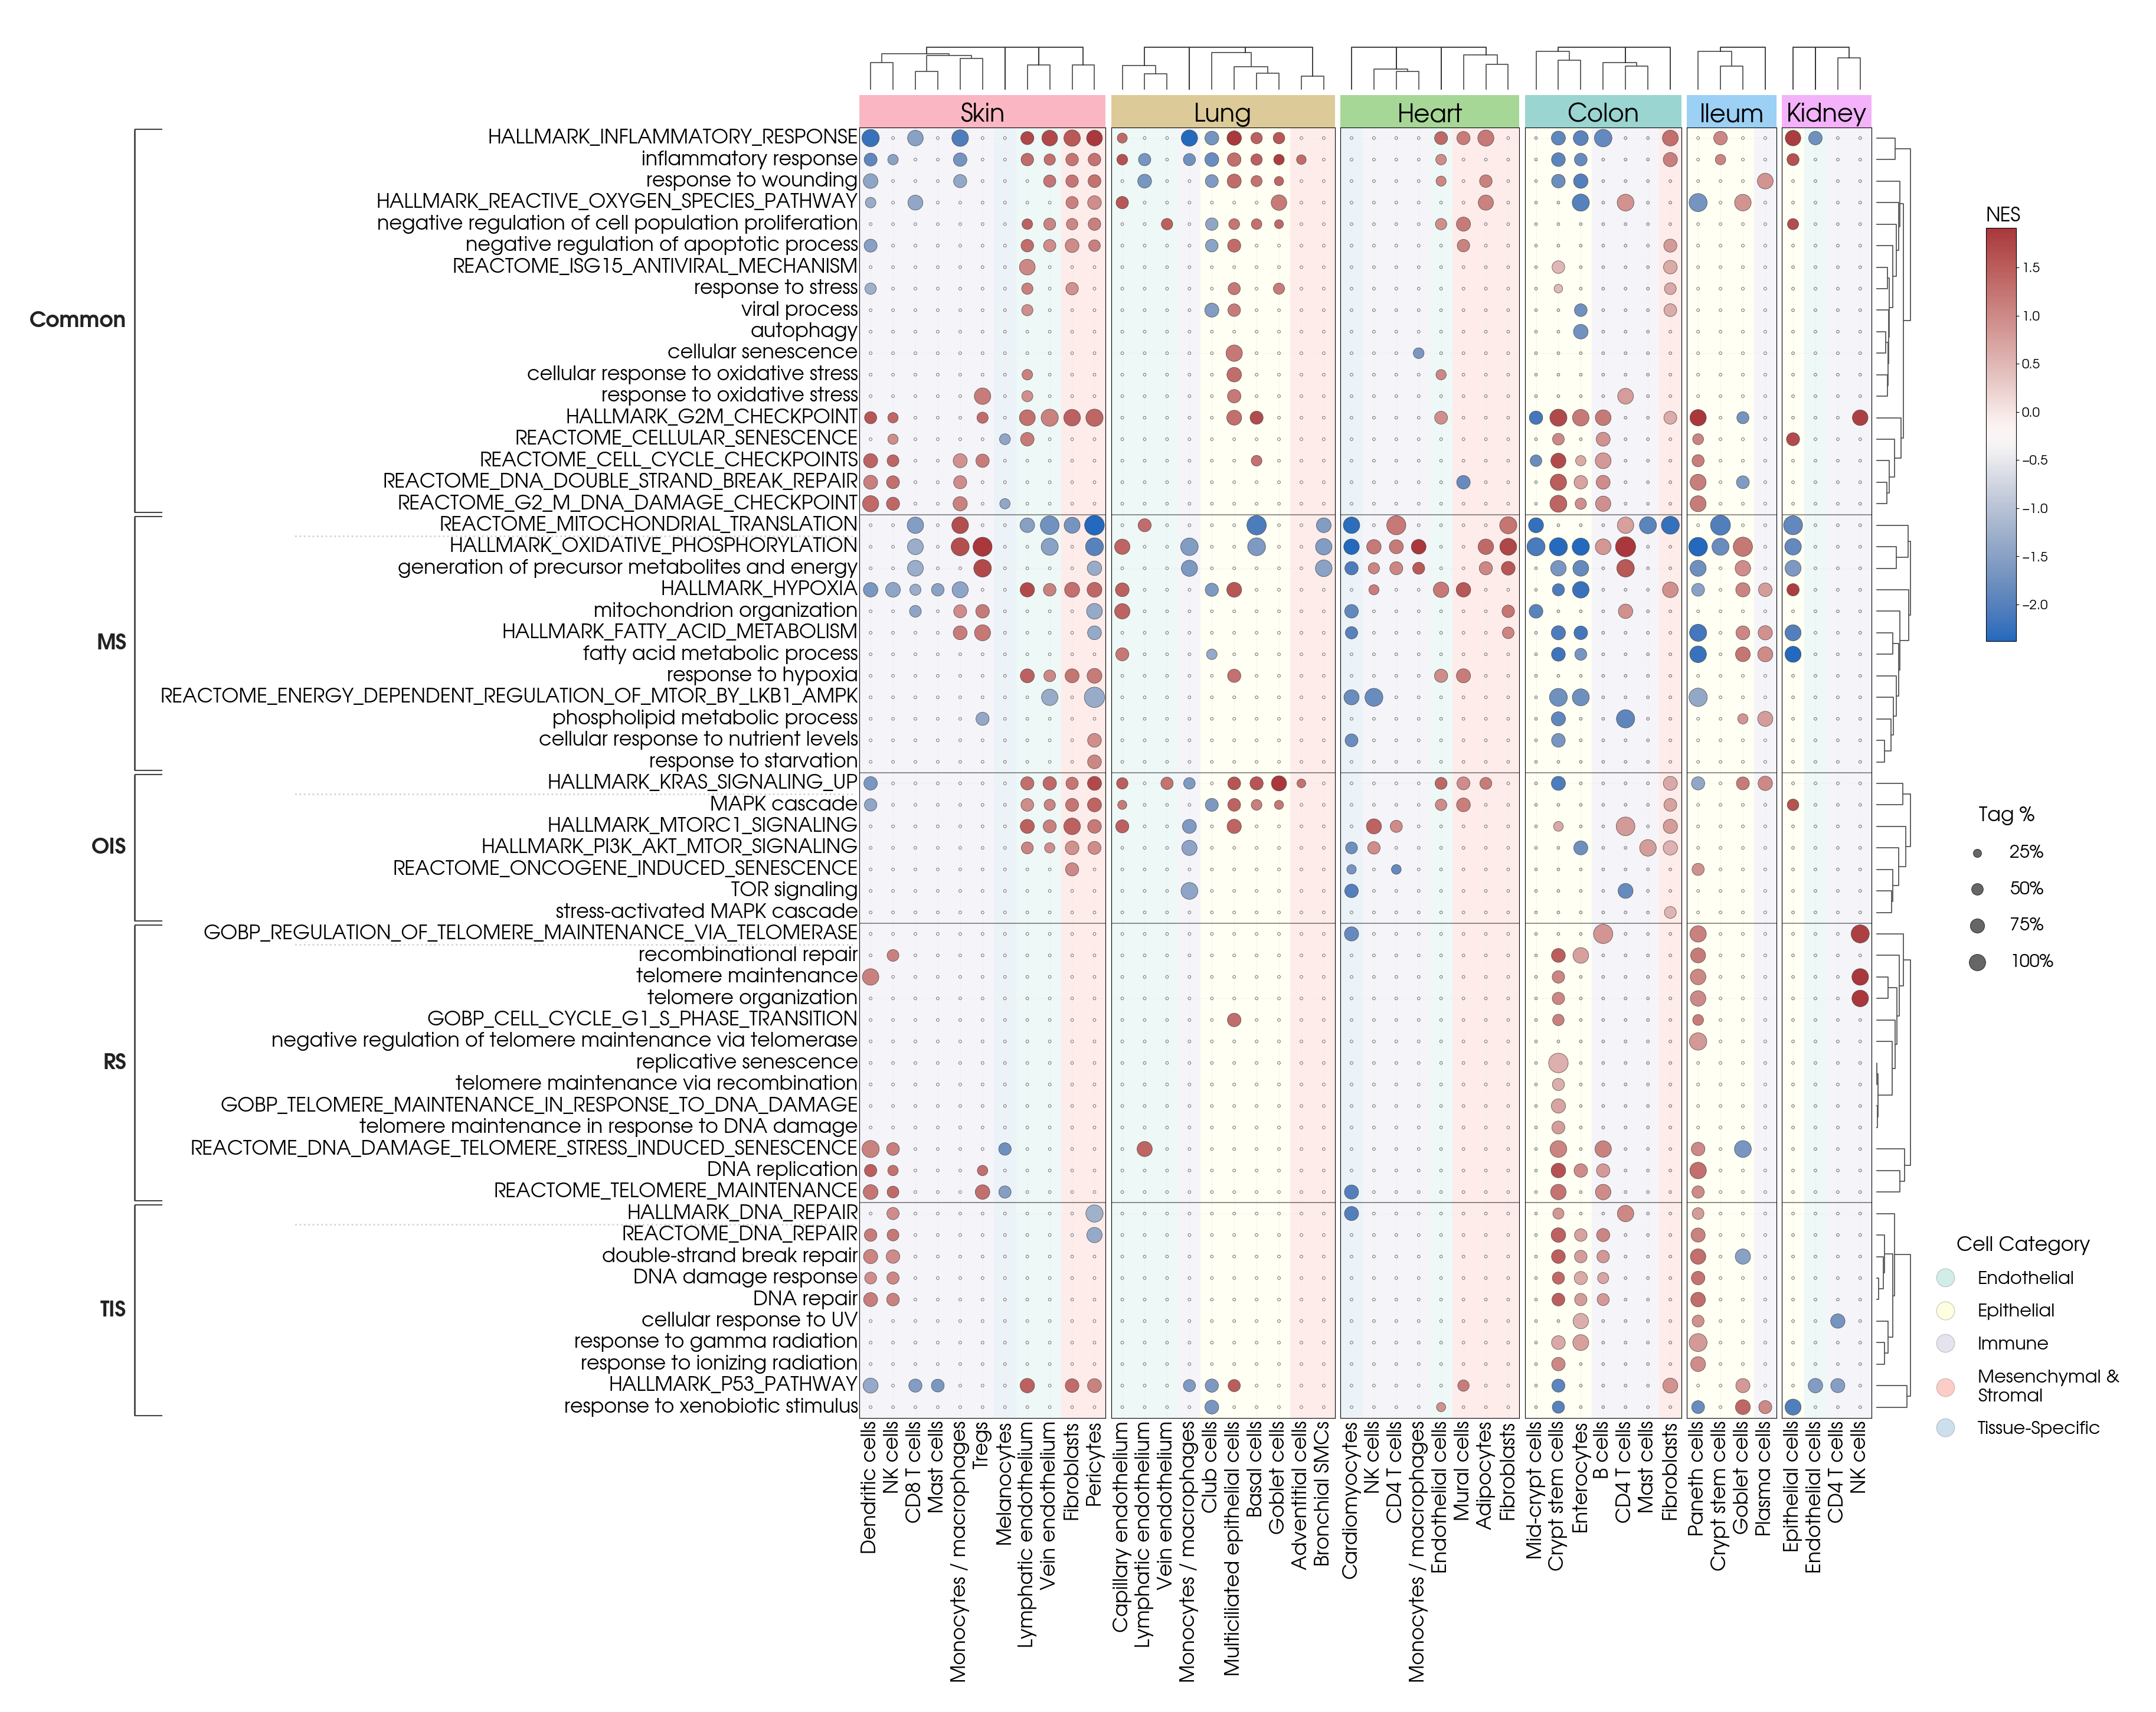

In [ ]:
# viz all terms

### merge terms

In [54]:
all_terms.head(1)

,Term_cat,Term,Term_id,geneSymbols,Ontology
0,Common,HALLMARK_INFLAMMATORY_RESPONSE,NaN,"[ABCA1, ABI1, ACVR1B, ACVR2A, ADGRE1, ADM, ADO...",HALLMARK


### prernkGSEA - merged terms

In [ ]:
out_path = "./data/sen_paper/2.6.1_merged_sen_prnkGsea_out.csv"

In [163]:
# GSEA для смердженных в категории терминов

merged_results = []
for t in tqdm(sorted(deg_df.Tissue.unique()), desc="Processing Tissues"):
    t_degs = deg_df[deg_df.Tissue == t]
    for ct in sorted(t_degs.cell_type.unique()):
        ct_degs = t_degs[t_degs.cell_type == ct].copy()
        min_fdr = ct_degs["FDR"][ct_degs["FDR"] > 0].min()
        fdr_clean = ct_degs["FDR"].replace(0, min_fdr)

        # 1. Создаем множество уникальных разрешенных генов (для супер-быстрого поиска)
        allowed_genes = set(ct_degs.index.dropna())

        # объединение генов из терминов + фильтр отсутствующих в ct_degs генов
        filtered_cat_dict = (
            all_terms.groupby("Term_cat")["geneSymbols"]
            .apply(
                lambda lists: list(
                    {
                        gene
                        for sublist in lists
                        for gene in sublist
                        if gene in allowed_genes
                    }
                )
            )
            .to_dict()
        )

        pre_res = gp.prerank(
            rnk=ct_degs.sort_values(by=["logFC", "FDR"], ascending=[False, True])[
                "logFC"
            ],
            outdir=None,
            gene_sets=filtered_cat_dict,
            ascending=None,
            min_size=2,
            max_size=10000,
            format=None,
            verbose=False,
        )
        res_df = pre_res.res2d
        res_df["Tissue"] = t
        res_df["cell_type"] = ct
        merged_results.append(res_df)
merged_df = pd.concat(merged_results)
# merged_df.to_csv(out_path)


In [164]:
merged_df.shape

(275, 12)

In [165]:
signif_df = merged_df[(merged_df["FDR q-val"] < 0.05) & (np.abs(merged_df.NES) > 0.5)]

In [166]:
signif_df.loc[:, "ct_category"] = signif_df["cell_type"].map(cell_type_to_category)

# 5. Задание строгого порядка категорий (критично для seaborn/matplotlib)
category_order = [
    "Immune",
    "Epithelial",
    "Endothelial",
    "Mesenchymal & Stromal",
    "Tissue-Specific",
]
signif_df.loc[:, "ct_category"] = pd.Categorical(
    signif_df["ct_category"], categories=category_order, ordered=True
)

signif_df.reset_index(drop=True, inplace=True)

# 2. Находим строки с максимальным NES по модулю среди Heart.Cell и Heart.Nuclei
heart_mask = signif_df["Tissue"].isin(["Heart_Cell", "Heart_Nuclei"])
heart_idx = (
    signif_df[heart_mask]["NES"]
    .abs()
    .groupby([signif_df["cell_type"], signif_df["Term"]])
    .idxmax()
)
signif_df.loc[signif_df["Tissue"].isin(["Heart_Cell", "Heart_Nuclei"]), "Tissue"] = (
    "Heart"
)

signif_df["cell_type"] = signif_df["cell_type"].replace(unif_cts)

# 5. Финальная зачистка дубликатов по всей таблице
signif_df.drop_duplicates(subset=["Tissue", "cell_type", "Term"], inplace=True)

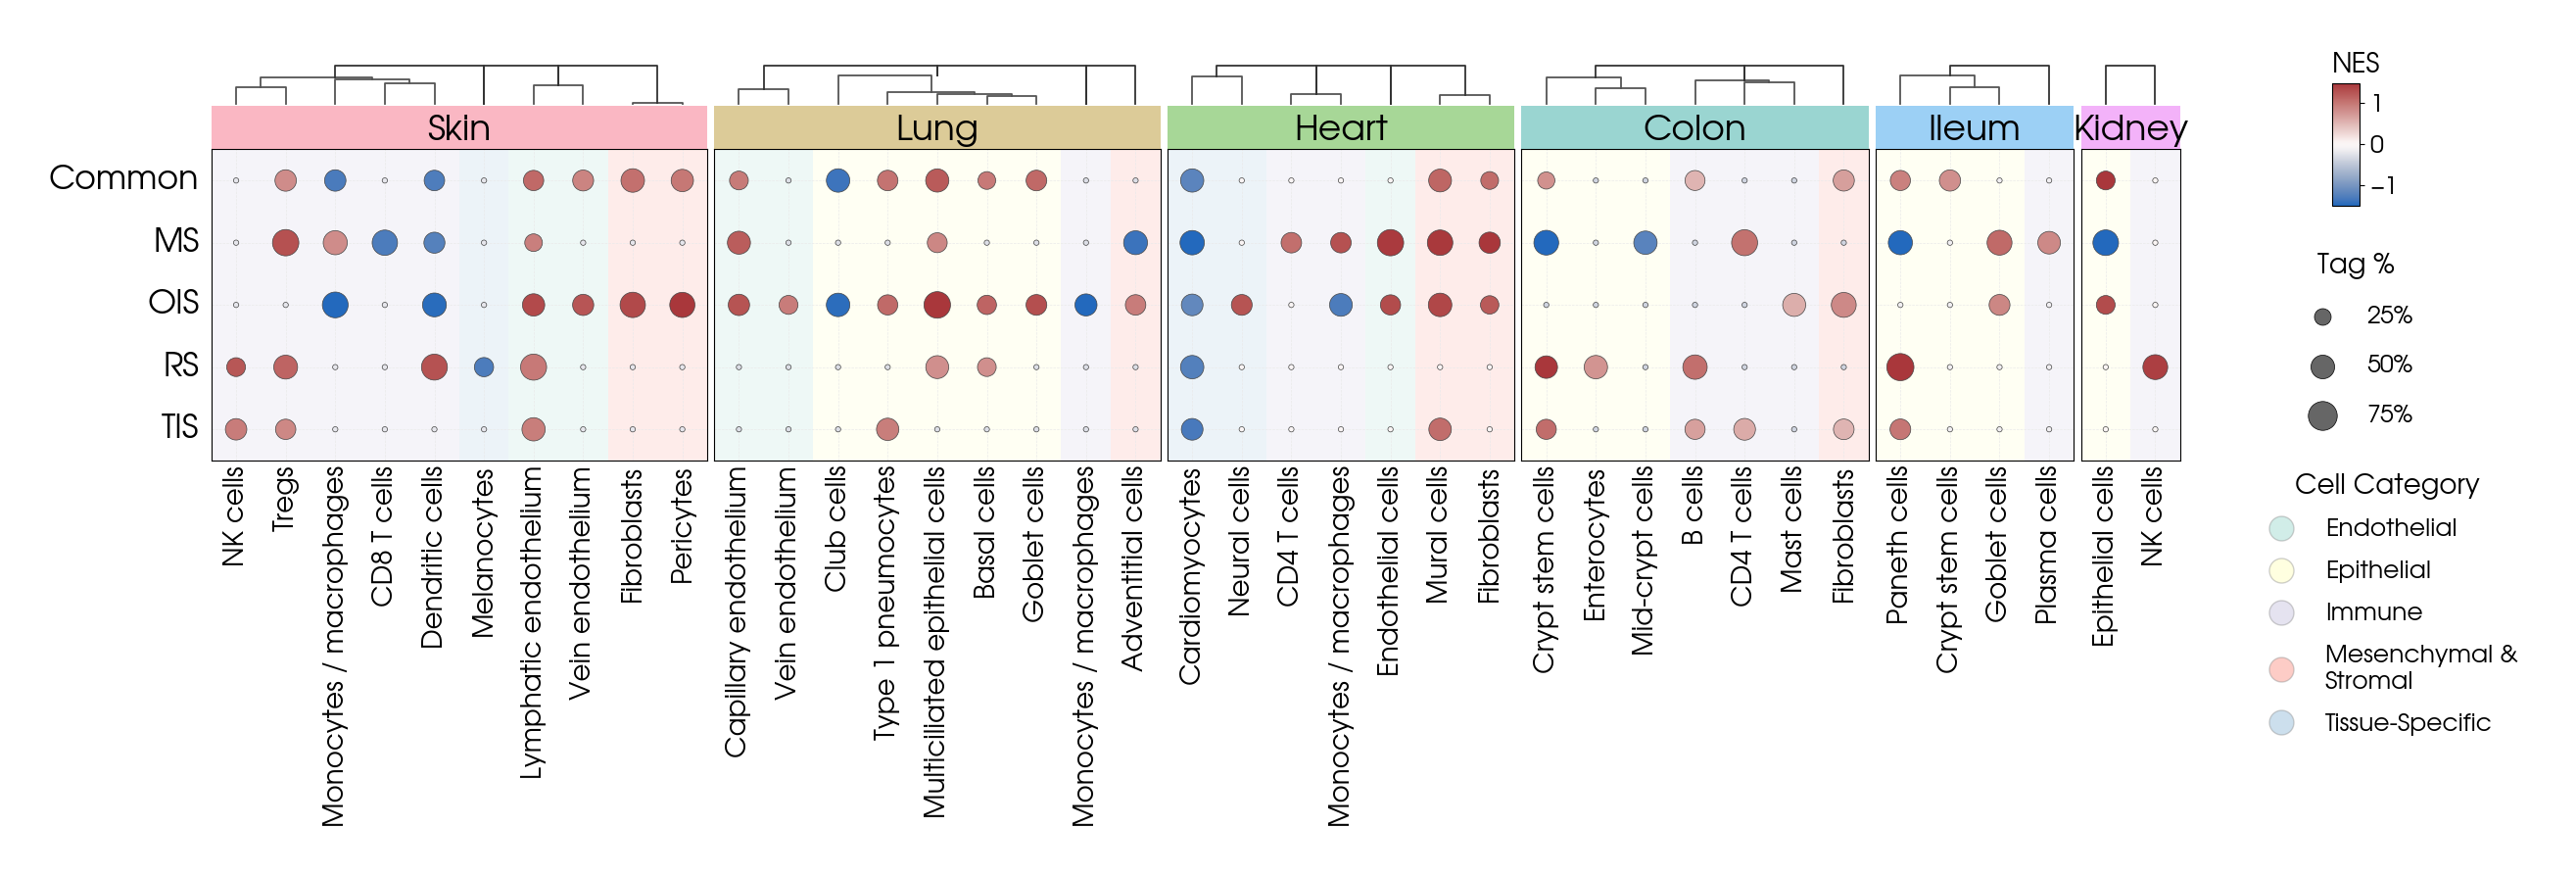

In [ ]:
# viz merged terms